In [1]:
import pandas as pd
import numpy as np

import sys
import warnings
import itertools
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path="/content/drive/MyDrive/PDSBA/PDS/FRA/Part A/CompData.xlsx"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_excel(path)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Co_Code,2058.0,1.757211e+04,2.189289e+04,4.000000,3.674000e+03,6.240000e+03,2.428075e+04,7.249300e+04
_Operating_Expense_Rate,2058.0,2.052389e+09,3.252624e+09,0.000100,1.578727e-04,3.330330e-04,4.110000e+09,9.980000e+09
_Research_and_development_expense_rate,2058.0,1.208634e+09,2.144568e+09,0.000000,0.000000e+00,1.994130e-04,1.550000e+09,9.980000e+09
_Cash_flow_rate,2058.0,4.652426e-01,2.266269e-02,0.000000,4.600991e-01,4.634450e-01,4.680691e-01,1.000000e+00
_Interest_bearing_debt_interest_rate,2058.0,1.113022e+07,9.042595e+07,0.000000,2.760280e-04,4.540450e-04,6.630660e-04,9.900000e+08
_Tax_rate_A,2058.0,1.147770e-01,1.524457e-01,0.000000,0.000000e+00,3.709890e-02,2.161909e-01,9.996963e-01
_Cash_Flow_Per_Share,1891.0,3.199856e-01,1.529979e-02,0.169449,3.149890e-01,3.206479e-01,3.259178e-01,4.622268e-01
_Per_Share_Net_profit_before_tax_Yuan_,2058.0,1.769673e-01,3.015730e-02,0.000000,1.666039e-01,1.756421e-01,1.858854e-01,7.923477e-01
_Realized_Sales_Gross_Profit_Growth_Rate,2058.0,2.276117e-02,2.170104e-02,0.004282,2.205831e-02,2.210001e-02,2.215200e-02,1.000000e+00
_Operating_Profit_Growth_Rate,2058.0,8.481083e-01,4.589093e-03,0.736430,8.479740e-01,8.480386e-01,8.481147e-01,1.000000e+00


In [5]:
df.head()

,Co_Code,Co_Name,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,...,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Net_Income_Flag,_Equity_to_Liability,Default
0,16974,Hind.Cables,8.820000e+09,0.000000e+00,0.462045,0.000352,0.001417,0.322558,0.194472,0.022074,...,0.310901,0.034913,0,0.028801,0.620927,0.026930,0.565744,1,0.015338,0
1,21214,Tata Tele. Mah.,9.380000e+09,4.230000e+09,0.460116,0.000716,0.000000,0.315520,0.161633,0.021902,...,0.314572,0.041653,0,0.006191,0.622513,0.026297,0.560741,1,0.029445,1
2,14852,ABG Shipyard,3.800000e+09,8.150000e+08,0.449893,0.000496,0.000000,0.299851,0.172554,0.022186,...,0.314777,0.033560,0,0.001095,0.623749,0.027276,0.566744,1,0.041718,0
3,2439,GTL,6.440000e+09,0.000000e+00,0.462731,0.000592,0.009313,0.319834,0.174738,0.027638,...,0.316974,0.016527,0,0.003749,0.622963,0.026988,0.565950,1,0.026956,0
4,23505,Bharati Defence,3.680000e+09,0.000000e+00,0.463117,0.000782,0.400243,0.325104,0.176546,0.022072,...,0.317729,0.034497,0,0.006595,0.624419,0.027498,0.567177,1,0.019900,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 58 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Co_Code                                            2058 non-null   int64  
 1   Co_Name                                            2058 non-null   object 
 2   _Operating_Expense_Rate                            2058 non-null   float64
 3   _Research_and_development_expense_rate             2058 non-null   float64
 4   _Cash_flow_rate                                    2058 non-null   float64
 5   _Interest_bearing_debt_interest_rate               2058 non-null   float64
 6   _Tax_rate_A                                        2058 non-null   float64
 7   _Cash_Flow_Per_Share                               1891 non-null   float64
 8   _Per_Share_Net_profit_before_tax_Yuan_             2058 non-null   float64
 9   _Realize

In [7]:
df.isnull().sum()

Co_Code                                                0
Co_Name                                                0
_Operating_Expense_Rate                                0
_Research_and_development_expense_rate                 0
_Cash_flow_rate                                        0
_Interest_bearing_debt_interest_rate                   0
_Tax_rate_A                                            0
_Cash_Flow_Per_Share                                 167
_Per_Share_Net_profit_before_tax_Yuan_                 0
_Realized_Sales_Gross_Profit_Growth_Rate               0
_Operating_Profit_Growth_Rate                          0
_Continuous_Net_Profit_Growth_Rate                     0
_Total_Asset_Growth_Rate                               0
_Net_Value_Growth_Rate                                 0
_Total_Asset_Return_Growth_Rate_Ratio                  0
_Cash_Reinvestment_perc                                0
_Current_Ratio                                         0
_Quick_Ratio                   

In [8]:
df.duplicated().sum()

0

In [9]:
print('The number of rows (observations) is',df.shape[0],'\n''The number of columns (variables) is',df.shape[1])

The number of rows (observations) is 2058 
The number of columns (variables) is 58


In [10]:
df['Default'].value_counts()

0    1838
1     220
Name: Default, dtype: int64

In [11]:
df['Default'].value_counts(normalize = True)*100

0    89.31001
1    10.68999
Name: Default, dtype: float64

In [12]:
df.size

119364

In [13]:
df.isnull().sum().sum()

298

In [14]:
(298/119364)*100

0.249656512851446

In [15]:
df_X = df.drop('Default', axis = 1)
df_Y = df['Default']

In [16]:
df_X

,Co_Code,Co_Name,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,...,_CFO_to_Assets,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Net_Income_Flag,_Equity_to_Liability
0,16974,Hind.Cables,8.820000e+09,0.000000e+00,0.462045,0.000352,0.001417,0.322558,0.194472,0.022074,...,0.576869,0.310901,0.034913,0,0.028801,0.620927,0.026930,0.565744,1,0.015338
1,21214,Tata Tele. Mah.,9.380000e+09,4.230000e+09,0.460116,0.000716,0.000000,0.315520,0.161633,0.021902,...,0.551523,0.314572,0.041653,0,0.006191,0.622513,0.026297,0.560741,1,0.029445
2,14852,ABG Shipyard,3.800000e+09,8.150000e+08,0.449893,0.000496,0.000000,0.299851,0.172554,0.022186,...,0.463045,0.314777,0.033560,0,0.001095,0.623749,0.027276,0.566744,1,0.041718
3,2439,GTL,6.440000e+09,0.000000e+00,0.462731,0.000592,0.009313,0.319834,0.174738,0.027638,...,0.577212,0.316974,0.016527,0,0.003749,0.622963,0.026988,0.565950,1,0.026956
4,23505,Bharati Defence,3.680000e+09,0.000000e+00,0.463117,0.000782,0.400243,0.325104,0.176546,0.022072,...,0.594038,0.317729,0.034497,0,0.006595,0.624419,0.027498,0.567177,1,0.019900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,2743,Kothari Ferment.,3.021580e-04,6.490000e+09,0.477066,0.000000,0.183014,0.322063,0.192739,0.022127,...,0.599051,0.320387,0.004430,0,0.000420,0.624567,0.026791,0.565158,1,0.171662
2054,21216,Firstobj.Tech.,1.371450e-04,0.000000e+00,0.465211,0.000658,0.000000,0.319764,0.169391,0.022072,...,0.583909,0.312324,0.032284,0,0.000882,0.624008,0.024201,0.573670,1,0.053740
2055,142,Diamines & Chem.,2.114990e-04,8.370000e+09,0.480248,0.000502,0.000000,0.327828,0.155005,0.021861,...,0.646378,0.313122,0.040998,0,0.009579,0.623718,0.026702,0.564697,1,0.054984
2056,18014,IL&FS Engg.,3.750000e+09,0.000000e+00,0.474670,0.000578,0.306205,0.322027,0.173834,0.022167,...,0.614016,0.315632,0.020275,0,0.004958,0.623443,0.026943,0.565792,1,0.057553


In [17]:
Q1 = df_X.quantile(0.05)
Q3 = df_X.quantile(0.95)
IQR = Q3 - Q1
UL = Q3 + 1.5*IQR
LL = Q1 - 1.5*IQR

In [18]:
df_X.isnull().sum()

Co_Code                                                0
Co_Name                                                0
_Operating_Expense_Rate                                0
_Research_and_development_expense_rate                 0
_Cash_flow_rate                                        0
_Interest_bearing_debt_interest_rate                   0
_Tax_rate_A                                            0
_Cash_Flow_Per_Share                                 167
_Per_Share_Net_profit_before_tax_Yuan_                 0
_Realized_Sales_Gross_Profit_Growth_Rate               0
_Operating_Profit_Growth_Rate                          0
_Continuous_Net_Profit_Growth_Rate                     0
_Total_Asset_Growth_Rate                               0
_Net_Value_Growth_Rate                                 0
_Total_Asset_Return_Growth_Rate_Ratio                  0
_Cash_Reinvestment_perc                                0
_Current_Ratio                                         0
_Quick_Ratio                   

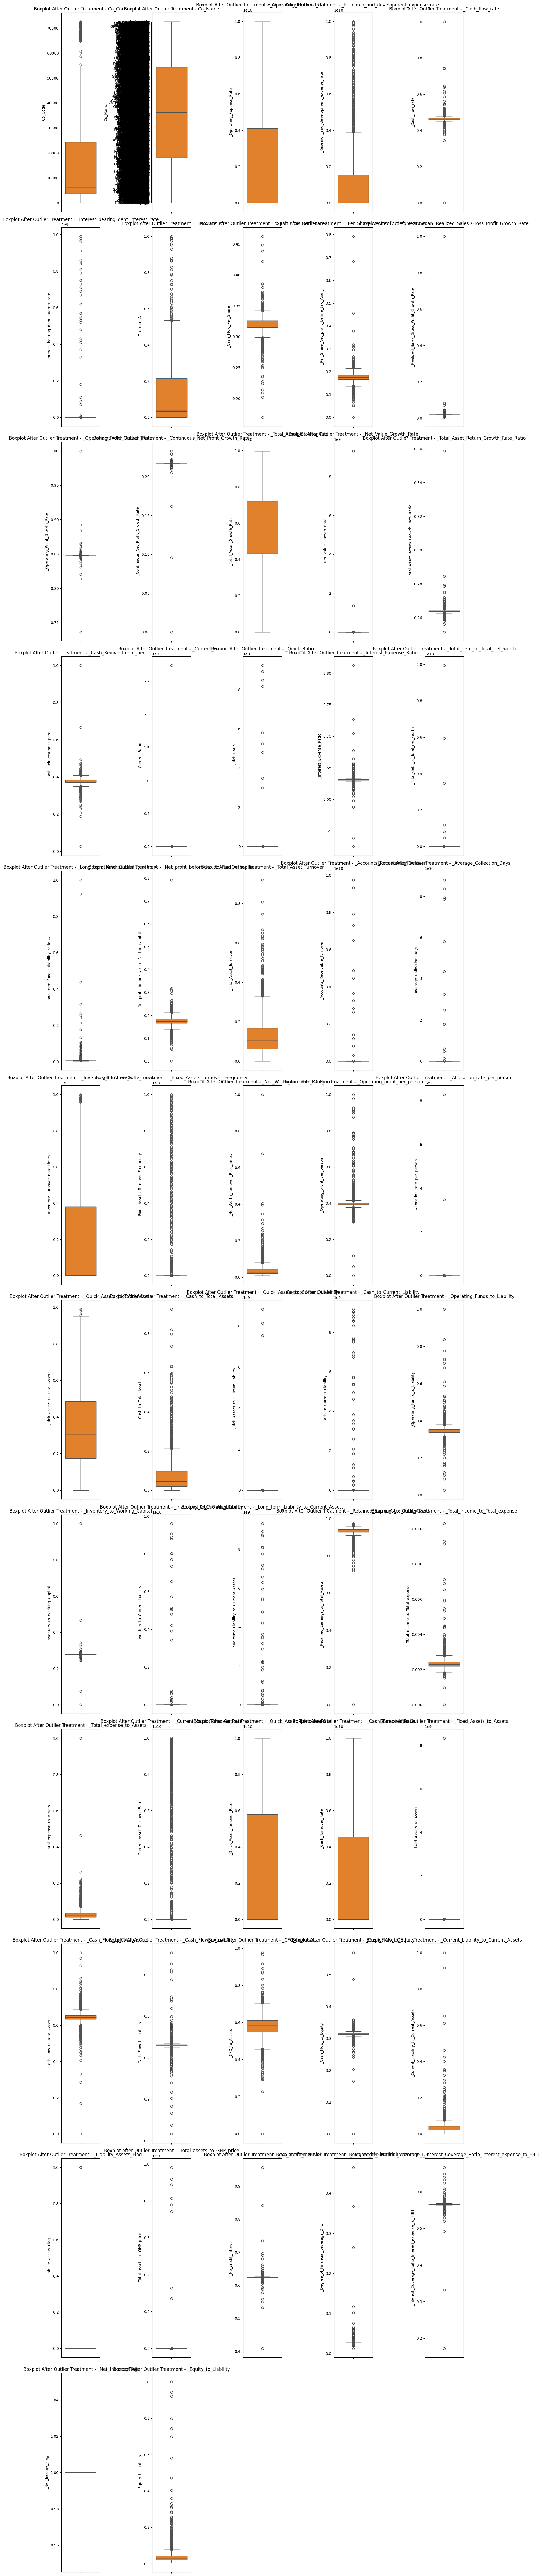

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import math

Q1 = df_X.quantile(0.05)
Q3 = df_X.quantile(0.95)

LL = Q1 - 1.5 * (Q3 - Q1)
UL = Q3 + 1.5 * (Q3 - Q1)

outliers_before = ((df_X > UL) | (df_X < LL)).sum()

df_X_cleaned = df_X.mask((df_X < LL) | (df_X > UL))

outliers_after = ((df_X_cleaned > UL) | (df_X_cleaned < LL)).sum()

num_cols = 5
num_vars = len(df_X.columns)
num_rows = math.ceil(num_vars / num_cols)

plt.figure(figsize=(16, 8 * num_rows))

for i, column in enumerate(df_X.columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(data=df_X[column])
    plt.title(f'Boxplot Before Outlier Treatment - {column}')

for i, column in enumerate(df_X_cleaned.columns[:60]):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(data=df_X_cleaned[column])
    plt.title(f'Boxplot After Outlier Treatment - {column}')
plt.tight_layout()
plt.show()

print("Outliers Before Treatment:")
print(outliers_before)
print("\nOutliers After Treatment:")
print(outliers_after)

In [20]:
df_X.isnull().sum().sum()

298

In [21]:
1576-298

1278

In [22]:
(1576/119364)*100

1.3203310881002648

In [23]:
df_X.shape

(2058, 57)

In [24]:
df_sub1 = pd.concat([df_X,df_Y], axis =1 )

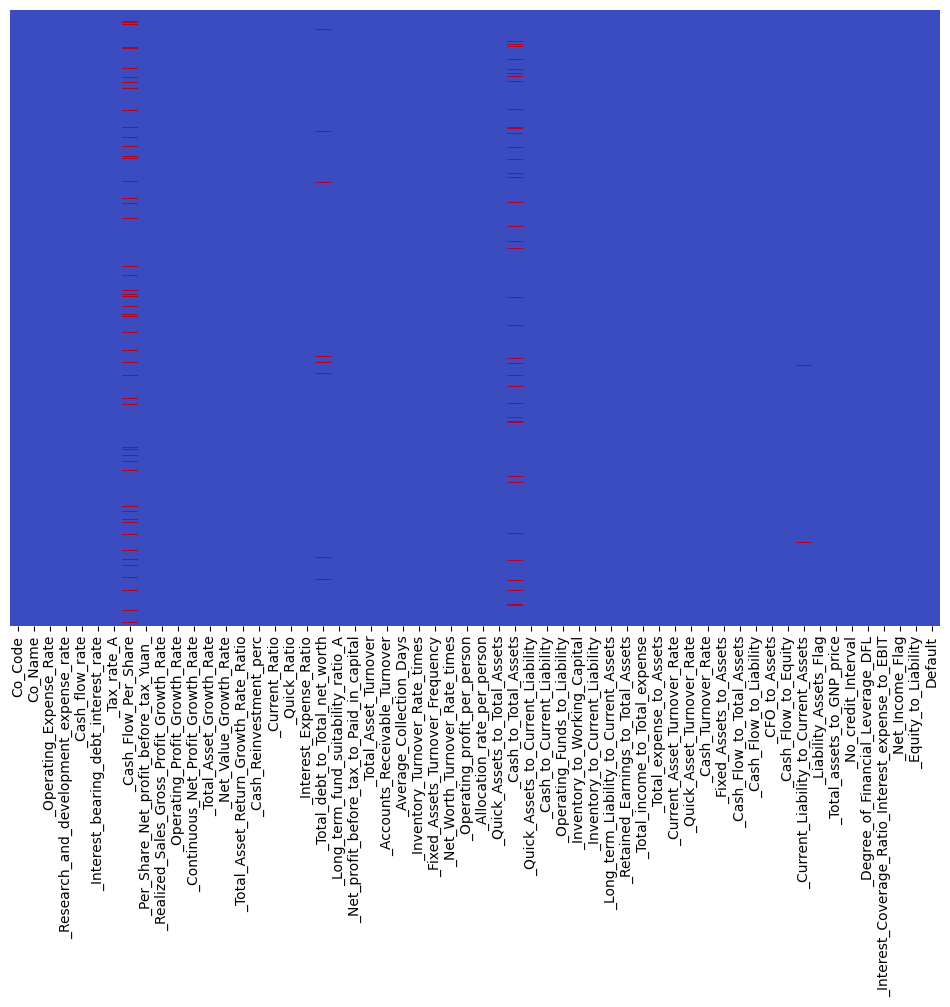

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(df_sub1.isnull(), cbar=False, cmap='coolwarm', yticklabels=False)
plt.show()

In [26]:
null_columns = df_sub1.columns[df_sub1.isnull().any()]
print(df_sub1[null_columns].isnull().sum())

_Cash_Flow_Per_Share                    167
_Total_debt_to_Total_net_worth           21
_Cash_to_Total_Assets                    96
_Current_Liability_to_Current_Assets     14
dtype: int64


In [41]:
import pandas as pd

df2 = df_sub1.fillna(df_sub1.mean())

print('Output after replacing the null values with mean values',df2.isnull().sum())

Output after replacing the null values with mean values Co_Code                                              0
Co_Name                                              0
_Operating_Expense_Rate                              0
_Research_and_development_expense_rate               0
_Cash_flow_rate                                      0
_Interest_bearing_debt_interest_rate                 0
_Tax_rate_A                                          0
_Cash_Flow_Per_Share                                 0
_Per_Share_Net_profit_before_tax_Yuan_               0
_Realized_Sales_Gross_Profit_Growth_Rate             0
_Operating_Profit_Growth_Rate                        0
_Continuous_Net_Profit_Growth_Rate                   0
_Total_Asset_Growth_Rate                             0
_Net_Value_Growth_Rate                               0
_Total_Asset_Return_Growth_Rate_Ratio                0
_Cash_Reinvestment_perc                              0
_Current_Ratio                                       0
_Quick_Ra

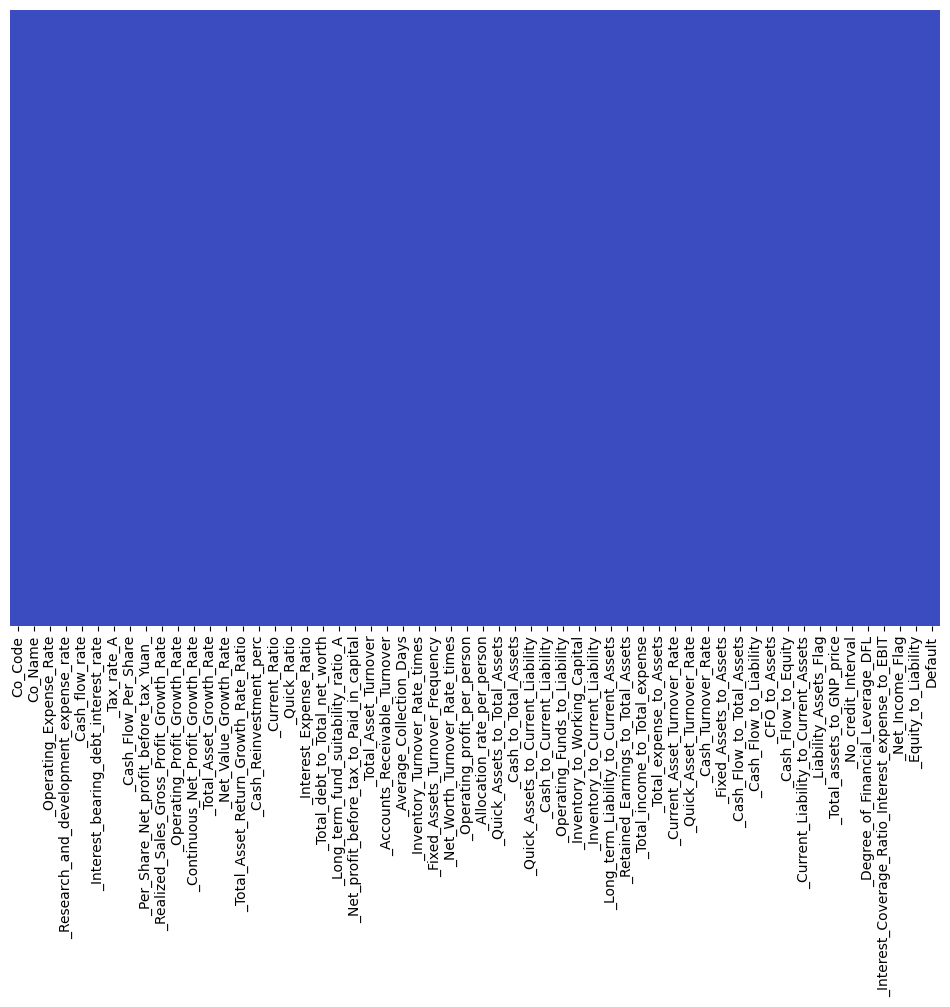

In [42]:
plt.figure(figsize=(12, 8))
sns.heatmap(df2.isnull(), cbar=False, cmap='coolwarm', yticklabels=False)
plt.show()

In [28]:
df2.head()

,Co_Code,Co_Name,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,...,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Net_Income_Flag,_Equity_to_Liability,Default
0,16974,Hind.Cables,8.820000e+09,0.000000e+00,0.462045,0.000352,0.001417,0.322558,0.194472,0.022074,...,0.310901,0.034913,0,0.028801,0.620927,0.026930,0.565744,1,0.015338,0
1,21214,Tata Tele. Mah.,9.380000e+09,4.230000e+09,0.460116,0.000716,0.000000,0.315520,0.161633,0.021902,...,0.314572,0.041653,0,0.006191,0.622513,0.026297,0.560741,1,0.029445,1
2,14852,ABG Shipyard,3.800000e+09,8.150000e+08,0.449893,0.000496,0.000000,0.299851,0.172554,0.022186,...,0.314777,0.033560,0,0.001095,0.623749,0.027276,0.566744,1,0.041718,0
3,2439,GTL,6.440000e+09,0.000000e+00,0.462731,0.000592,0.009313,0.319834,0.174738,0.027638,...,0.316974,0.016527,0,0.003749,0.622963,0.026988,0.565950,1,0.026956,0
4,23505,Bharati Defence,3.680000e+09,0.000000e+00,0.463117,0.000782,0.400243,0.325104,0.176546,0.022072,...,0.317729,0.034497,0,0.006595,0.624419,0.027498,0.567177,1,0.019900,0


Index(['Co_Code', 'Co_Name', '_Operating_Expense_Rate',
       '_Research_and_development_expense_rate', '_Cash_flow_rate',
       '_Interest_bearing_debt_interest_rate', '_Tax_rate_A',
       '_Cash_Flow_Per_Share', '_Per_Share_Net_profit_before_tax_Yuan_',
       '_Realized_Sales_Gross_Profit_Growth_Rate',
       '_Operating_Profit_Growth_Rate', '_Continuous_Net_Profit_Growth_Rate',
       '_Total_Asset_Growth_Rate', '_Net_Value_Growth_Rate',
       '_Total_Asset_Return_Growth_Rate_Ratio', '_Cash_Reinvestment_perc',
       '_Current_Ratio', '_Quick_Ratio', '_Interest_Expense_Ratio',
       '_Total_debt_to_Total_net_worth', '_Long_term_fund_suitability_ratio_A',
       '_Net_profit_before_tax_to_Paid_in_capital', '_Total_Asset_Turnover',
       '_Accounts_Receivable_Turnover', '_Average_Collection_Days',
       '_Inventory_Turnover_Rate_times', '_Fixed_Assets_Turnover_Frequency',
       '_Net_Worth_Turnover_Rate_times', '_Operating_profit_per_person',
       '_Allocation_rate_per_pers

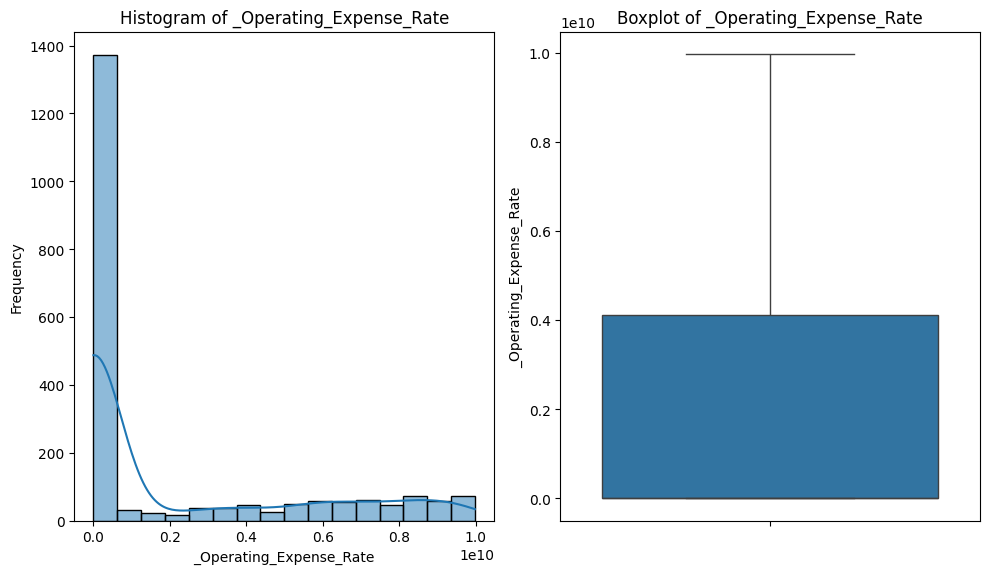

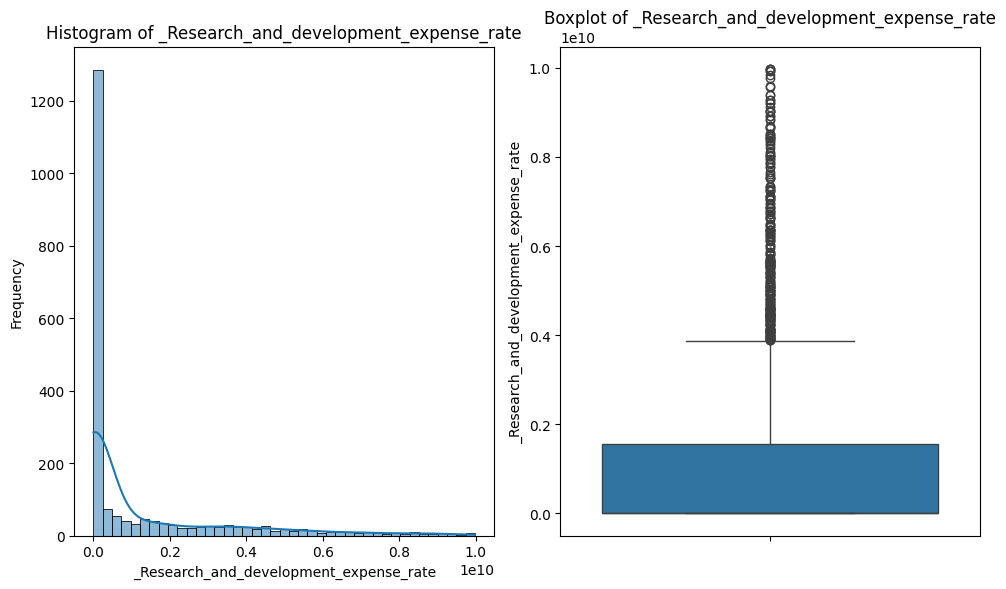

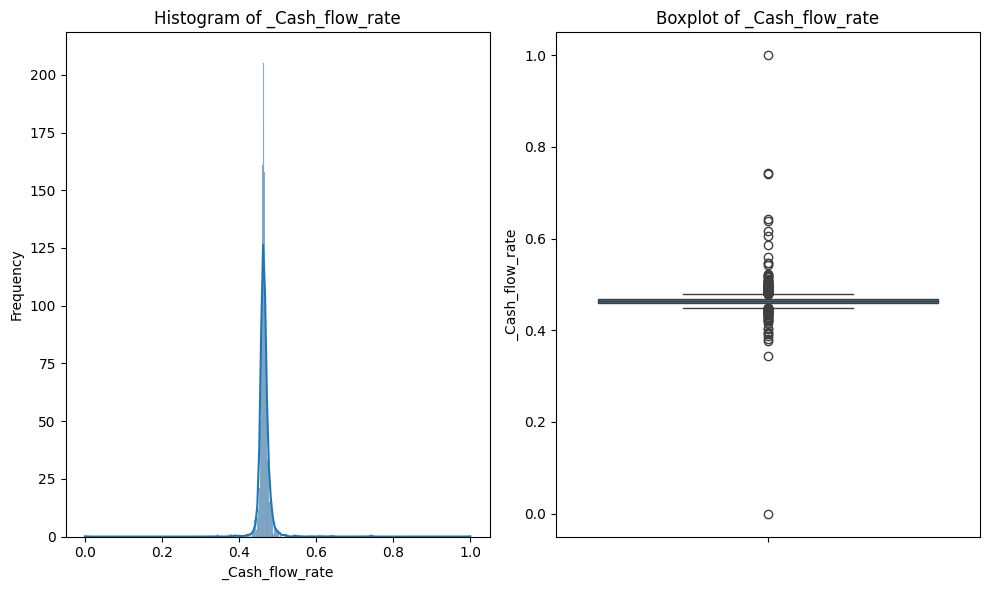

MemoryError: Unable to allocate 118. TiB for an array with shape (16267970726812,) and data type float64

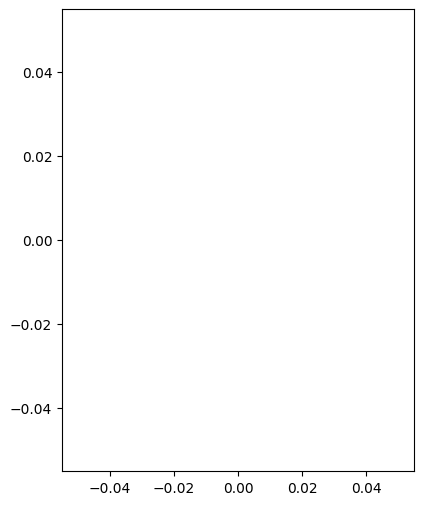

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df2.columns)

variables = ['_Operating_Expense_Rate', '_Research_and_development_expense_rate', '_Cash_flow_rate',
             '_Interest_bearing_debt_interest_rate', '_Tax_rate_A', '_Cash_Flow_Per_Share',
             '_Per_Share_Net_profit_before_tax_Yuan_', '_Realized_Sales_Gross_Profit_Growth_Rate',
             '_Cash_Flow_to_Equity', '_Current_Liability_to_Current_Assets', '_Liability_Assets_Flag',
             '_Total_assets_to_GNP_price', '_No_credit_Interval', '_Degree_of_Financial_Leverage_DFL',
             '_Interest_Coverage_Ratio_Interest_expense_to_EBIT', '_Net_Income_Flag', '_Equity_to_Liability', 'Default']

for var in variables:
    plt.figure(figsize=(10, 6))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df2[var], kde=True)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df2[var])
    plt.title(f'Boxplot of {var}')
    plt.ylabel(var)

    plt.tight_layout()
    plt.show()



<Axes: >

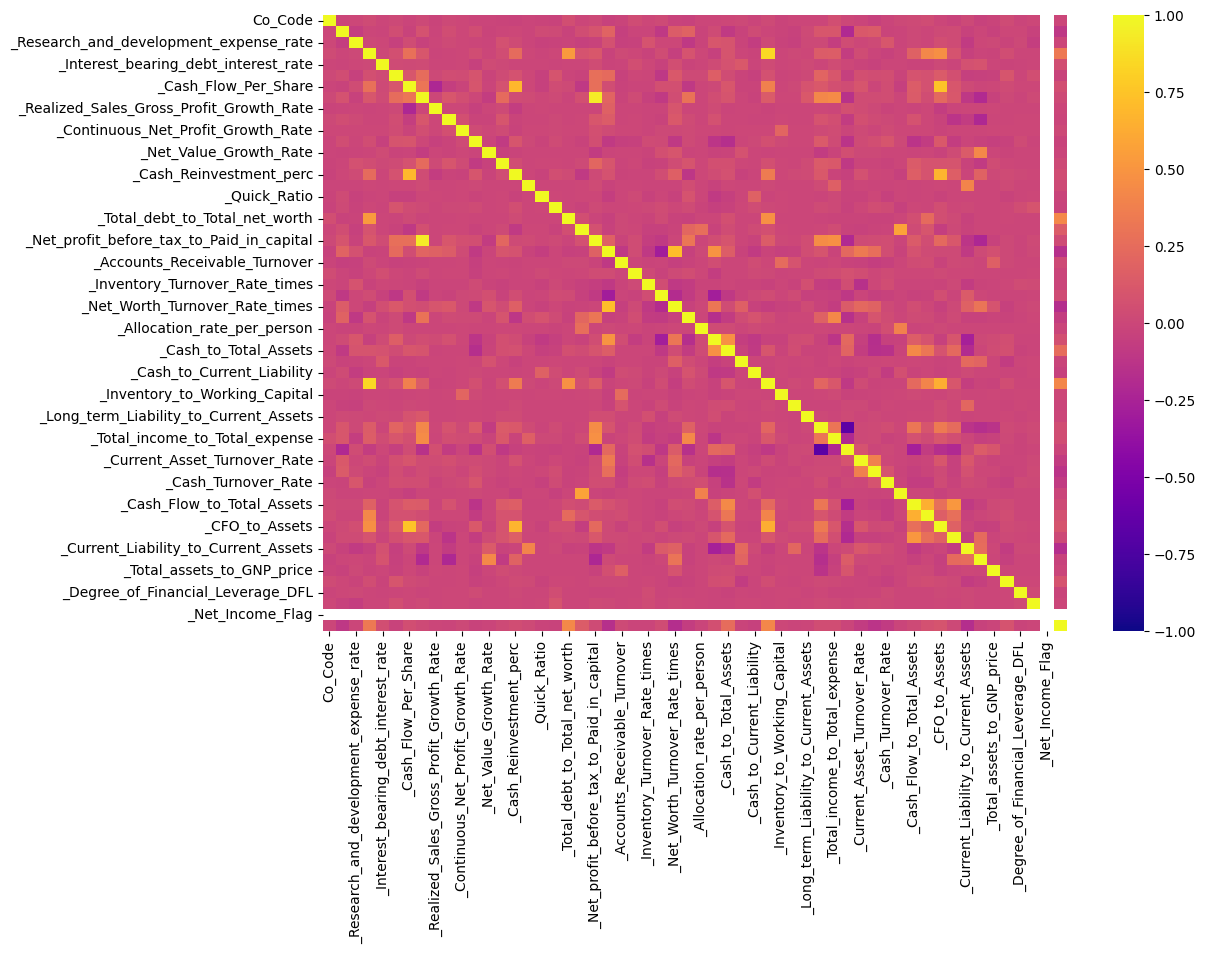

In [63]:
plt.figure(figsize = (12,8))
cor_matrix = df2.drop('Default', axis = 1).corr()
sns.heatmap(cor_matrix, cmap = 'plasma', vmin = -1, vmax= 1)


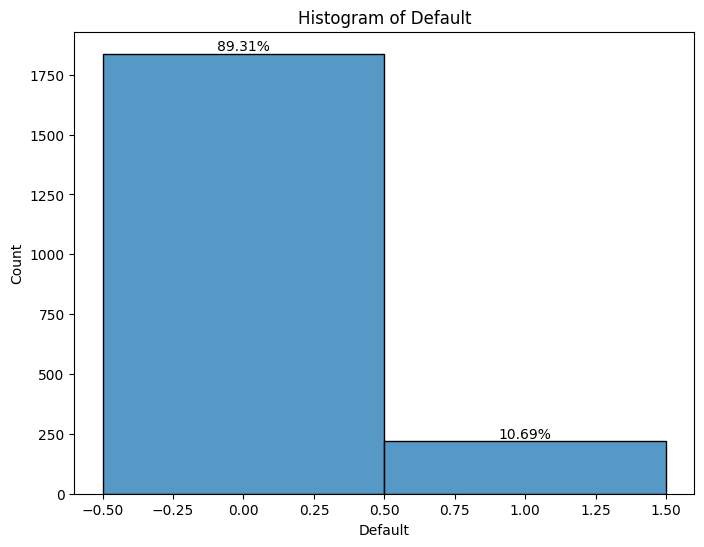

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df2['Default'], bins=2, discrete=True)
total_count = df2['Default'].shape[0]
counts = df2['Default'].value_counts()
for i, count in enumerate(counts):
    percentage = count / total_count * 100
    plt.text(i, count, f'{percentage:.2f}%', ha='center', va='bottom')

plt.title('Histogram of Default')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

In [52]:
default_1_companies = df2[df2['Default'] == 1]['Co_Name']

print("Company Names with Default = 1:")
print(default_1_companies)

Company Names with Default = 1:
1        Tata Tele. Mah.
11       Electrotherm(I)
15           Ricoh India
20                   LML
26                   NRC
              ...       
2017    Vibrant Glo. Cap
2024      KM Sugar Mills
2039     Gini Silk Mills
2040         Tasty Dairy
2043       Krypton Inds.
Name: Co_Name, Length: 220, dtype: object


In [49]:
default_1_companies.count()

220

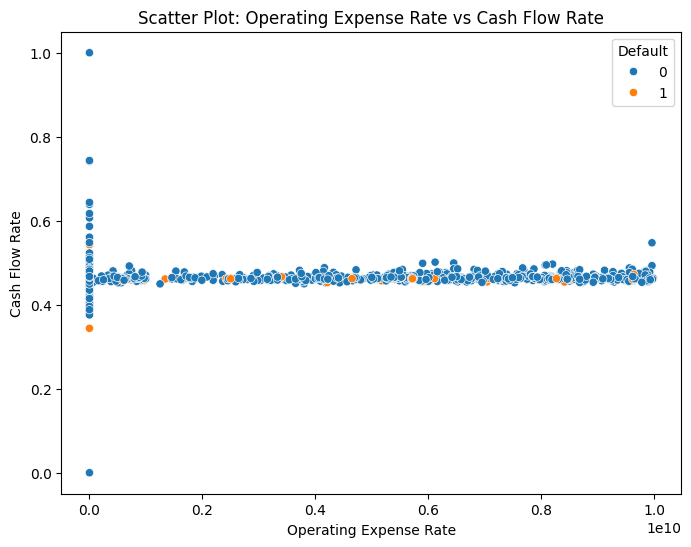

In [67]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='_Operating_Expense_Rate', y='_Cash_flow_rate', data=df2, hue='Default')
plt.title('Scatter Plot: Operating Expense Rate vs Cash Flow Rate')
plt.xlabel('Operating Expense Rate')
plt.ylabel('Cash Flow Rate')
plt.legend(title='Default')
plt.show()


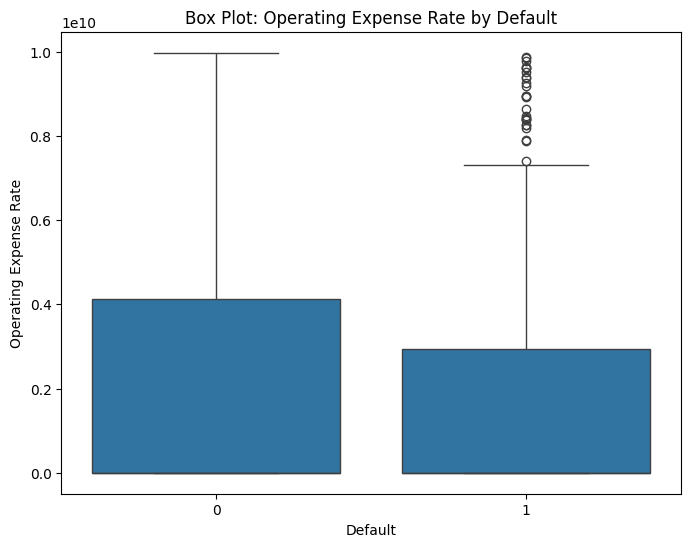

In [68]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Default', y='_Operating_Expense_Rate', data=df2)
plt.title('Box Plot: Operating Expense Rate by Default')
plt.xlabel('Default')
plt.ylabel('Operating Expense Rate')
plt.show()

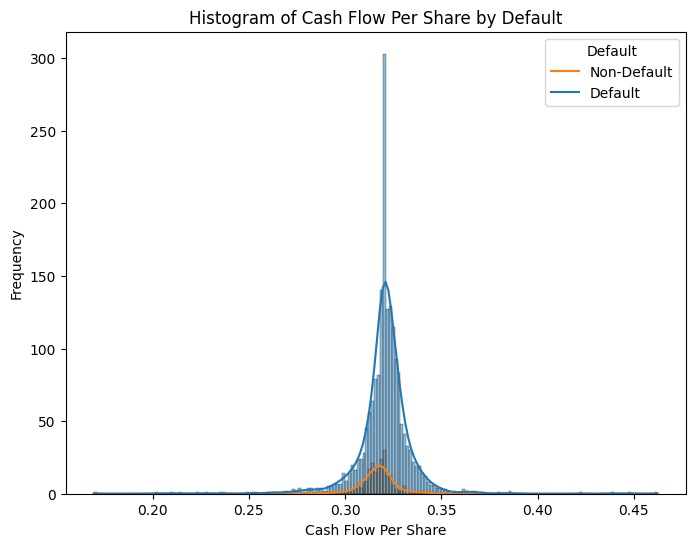

In [72]:
plt.figure(figsize=(8, 6))
sns.histplot(x='_Cash_Flow_Per_Share', data=df2, hue='Default', kde=True)
plt.title('Histogram of Cash Flow Per Share by Default')
plt.xlabel('Cash Flow Per Share')
plt.ylabel('Frequency')
plt.legend(title='Default', labels=['Non-Default', 'Default'])
plt.show()



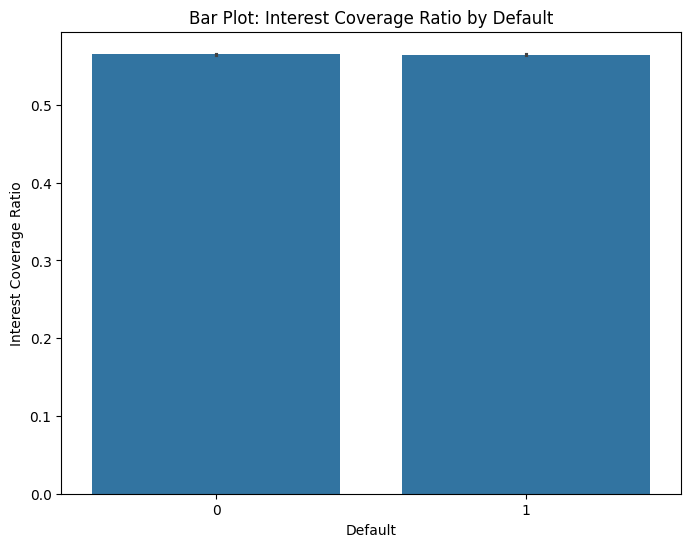

In [79]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Default', y='_Interest_Coverage_Ratio_Interest_expense_to_EBIT', data=df2)
plt.title('Bar Plot: Interest Coverage Ratio by Default')
plt.xlabel('Default')
plt.ylabel('Interest Coverage Ratio')
plt.show()


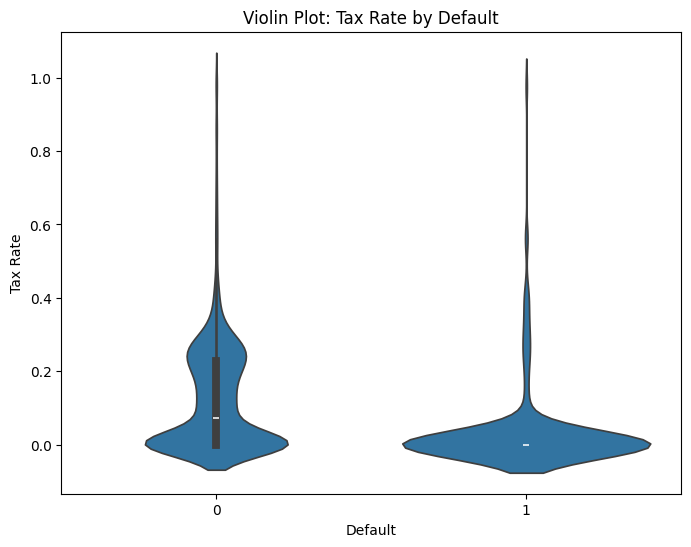

In [80]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Default', y='_Tax_rate_A', data=df2)
plt.title('Violin Plot: Tax Rate by Default')
plt.xlabel('Default')
plt.ylabel('Tax Rate')
plt.show()

In [64]:
unique_company_count = df2['Co_Name'].nunique()

print("Unique Count of Company Names:", unique_company_count)

Unique Count of Company Names: 2058


In [65]:
from sklearn.model_selection import train_test_split
import pandas as pd

X = df.drop(columns=['Default'])
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


In [57]:
from sklearn.model_selection import train_test_split
import pandas as pd

print("Head of the DataFrame:")
print(df.head())

print("\nCount of train data:")
print(X_train.shape[0])
print("\nCount of test data:")
print(X_test.shape[0])

X = df.drop(columns=['Default'])  # Features
y = df['Default']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

Head of the DataFrame:
   Co_Code          Co_Name  _Operating_Expense_Rate  \
0    16974      Hind.Cables             8.820000e+09   
1    21214  Tata Tele. Mah.             9.380000e+09   
2    14852     ABG Shipyard             3.800000e+09   
3     2439              GTL             6.440000e+09   
4    23505  Bharati Defence             3.680000e+09   

   _Research_and_development_expense_rate  _Cash_flow_rate  \
0                            0.000000e+00         0.462045   
1                            4.230000e+09         0.460116   
2                            8.150000e+08         0.449893   
3                            0.000000e+00         0.462731   
4                            0.000000e+00         0.463117   

   _Interest_bearing_debt_interest_rate  _Tax_rate_A  _Cash_Flow_Per_Share  \
0                              0.000352     0.001417              0.322558   
1                              0.000716     0.000000              0.315520   
2                              0.

In [81]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd
import numpy as np

important_vars = ['_Operating_Expense_Rate', '_Cash_flow_rate', '_Interest_bearing_debt_interest_rate', '_Tax_rate_A', '_Cash_Flow_Per_Share']

df_selected = df2[important_vars + ['Default']]

X = df_selected.drop(columns=['Default'])
y = df_selected['Default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


X_train_const = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_const)
logit_result = logit_model.fit()

print(logit_result.summary())

X_test_const = sm.add_constant(X_test)
y_pred_prob = logit_result.predict(X_test_const)


Optimization terminated successfully.
         Current function value: 0.318781
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                Default   No. Observations:                 1378
Model:                          Logit   Df Residuals:                     1372
Method:                           MLE   Df Model:                            5
Date:                Sun, 25 Feb 2024   Pseudo R-squ.:                 0.08571
Time:                        14:17:00   Log-Likelihood:                -439.28
converged:                       True   LL-Null:                       -480.46
Covariance Type:            nonrobust   LLR p-value:                 2.691e-16
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    4.1692      2.2

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

auc_score = roc_auc_score(y_test, y_pred_prob)
print("AUC Score:", auc_score)

optimal_cutoff_index = np.argmax(tpr - fpr)
optimal_cutoff = thresholds[optimal_cutoff_index]
print("Optimum Cutoff:", optimal_cutoff)



AUC Score: 0.7552774463733535
Optimum Cutoff: 0.15749238747749514


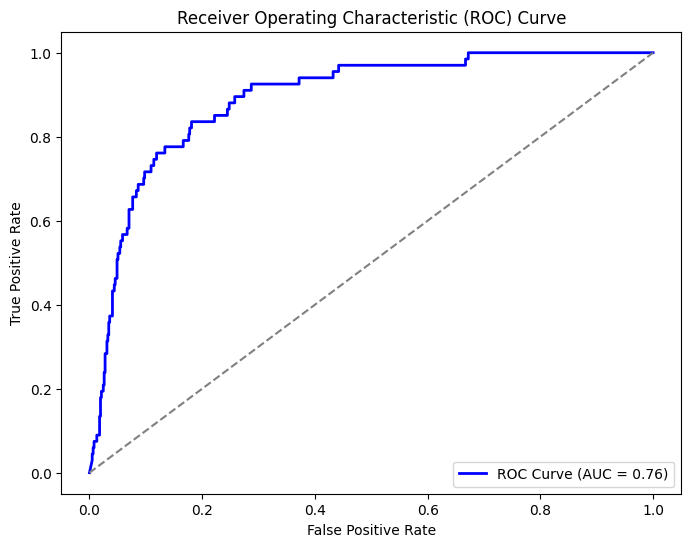

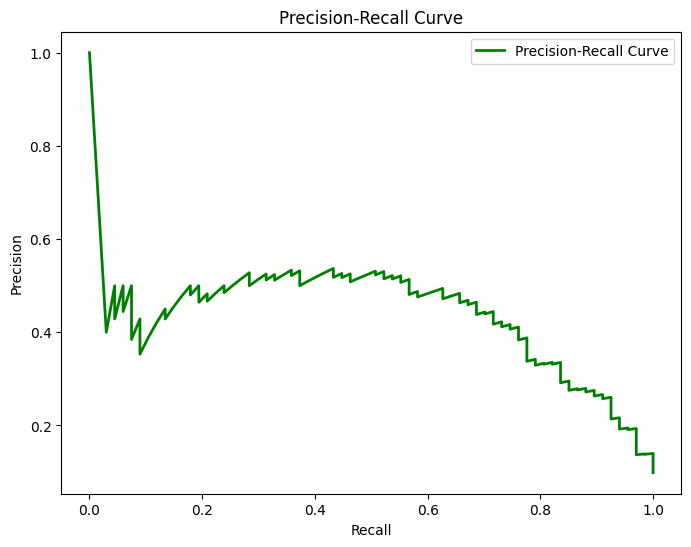

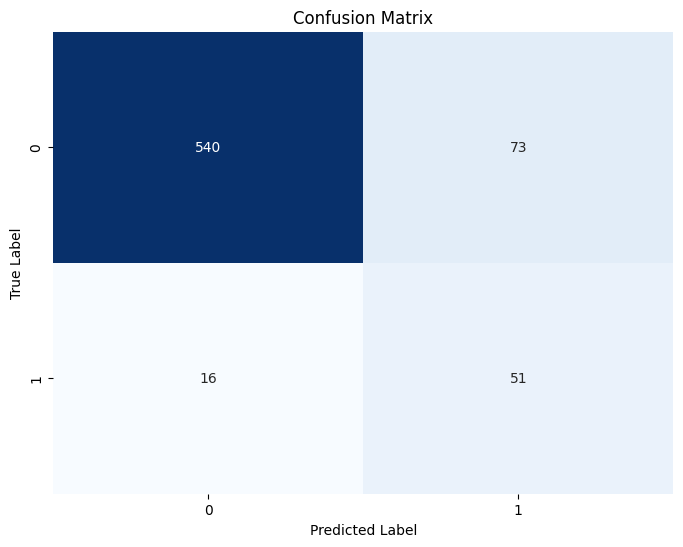

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, confusion_matrix

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.show()

y_pred_binary = np.where(y_pred_prob >= optimal_cutoff, 1, 0)
conf_matrix = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

X = df2.drop(columns=['Co_Code', 'Co_Name', 'Default'])
y = df2['Default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train_const = sm.add_constant(X_train)  # Add constant term
logit_model = sm.Logit(y_train, X_train_const)
logit_result = logit_model.fit()

X_test_const = sm.add_constant(X_test)
y_pred_prob = logit_result.predict(X_test_const)
y_pred_binary = np.where(y_pred_prob >= 0.5, 1, 0)

accuracy_test = accuracy_score(y_test, y_pred_binary)
precision_test = precision_score(y_test, y_pred_binary)
recall_test = recall_score(y_test, y_pred_binary)
f1_test = f1_score(y_test, y_pred_binary)
roc_auc_test = roc_auc_score(y_test, y_pred_prob)

print("Performance Metrics on Test Dataset:")
print(f"Accuracy: {accuracy_test}")
print(f"Precision: {precision_test}")
print(f"Recall: {recall_test}")
print(f"F1-Score: {f1_test}")
print(f"ROC-AUC Score: {roc_auc_test}")

         Current function value: 0.189433
         Iterations: 35
Performance Metrics on Test Dataset:
Accuracy: 0.9058823529411765
Precision: 0.5283018867924528
Recall: 0.417910447761194
F1-Score: 0.4666666666666667
ROC-AUC Score: 0.8919432202770812


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


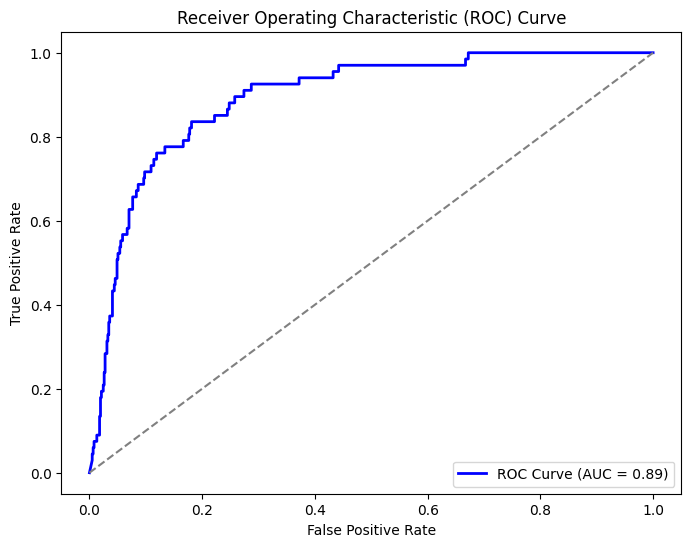

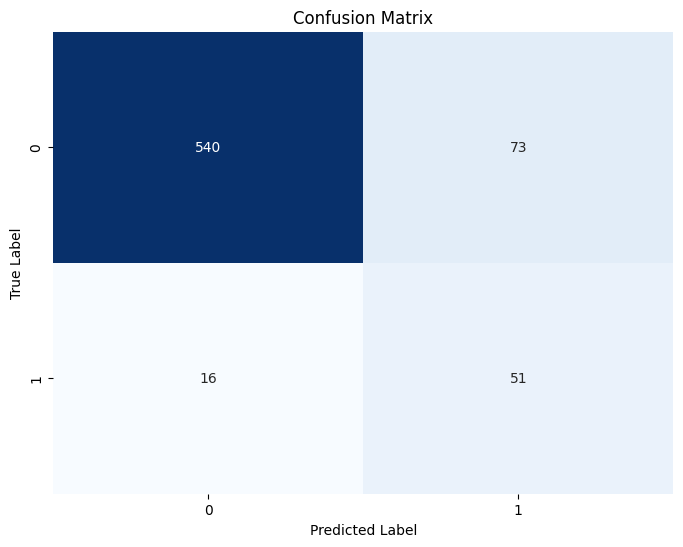

Confusion Matrix:
[[599  14]
 [ 40  27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       613
           1       0.66      0.40      0.50        67

    accuracy                           0.92       680
   macro avg       0.80      0.69      0.73       680
weighted avg       0.91      0.92      0.91       680



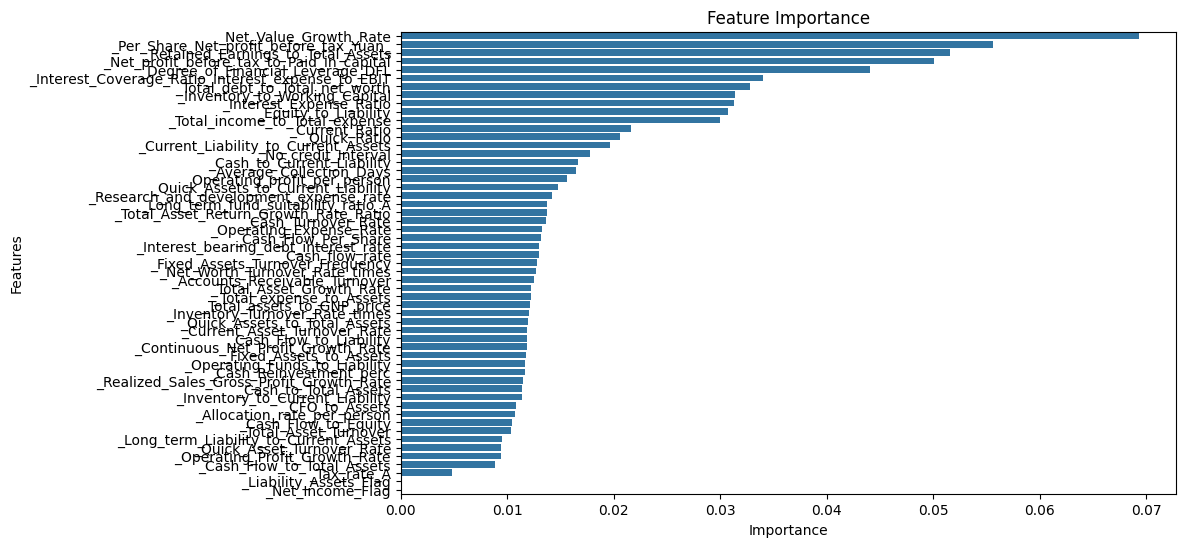

In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

X = df2.drop(columns=['Co_Code', 'Co_Name', 'Default'])
y = df2['Default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
sorted_importance = feature_importance.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importance, y=sorted_importance.index)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


Performance Metrics on Test Dataset:
Accuracy: 0.9205882352941176
Precision: 0.6585365853658537
Recall: 0.40298507462686567
F1-Score: 0.5
ROC-AUC Score: 0.9294270896739791


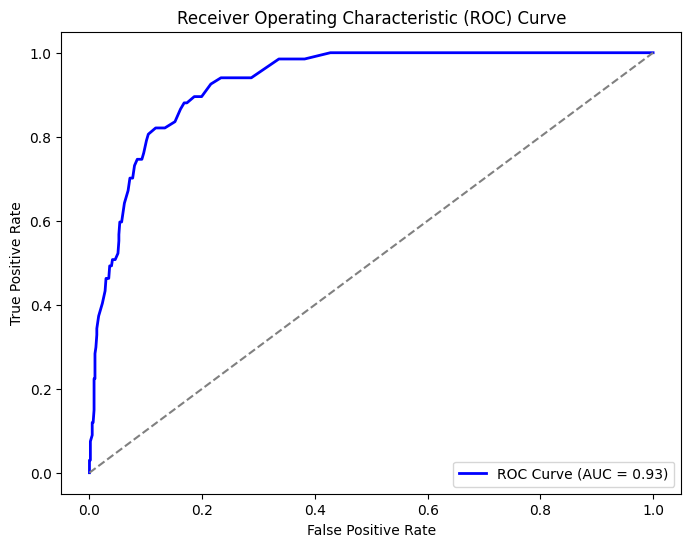

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Performance Metrics on Test Dataset:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()



Accuracy: 0.8852941176470588
Confusion Matrix:
 [[576  37]
 [ 41  26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94       613
           1       0.41      0.39      0.40        67

    accuracy                           0.89       680
   macro avg       0.67      0.66      0.67       680
weighted avg       0.88      0.89      0.88       680



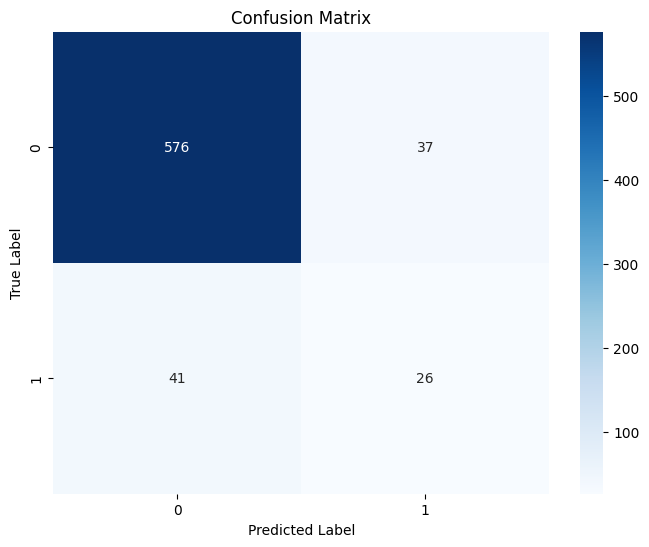

In [84]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

X = df2.drop(columns=['Co_Code', 'Co_Name', 'Default'])  # Features
y = df2['Default']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

y_pred = lda_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [85]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_test = lda_model.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred_test)
conf_matrix_test = confusion_matrix(y_test, y_pred_test)
class_report_test = classification_report(y_test, y_pred_test)

print("Performance Metrics on Test Dataset:")
print("Accuracy:", accuracy_test)
print("Confusion Matrix:\n", conf_matrix_test)
print("Classification Report:\n", class_report_test)


Performance Metrics on Test Dataset:
Accuracy: 0.8852941176470588
Confusion Matrix:
 [[576  37]
 [ 41  26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94       613
           1       0.41      0.39      0.40        67

    accuracy                           0.89       680
   macro avg       0.67      0.66      0.67       680
weighted avg       0.88      0.89      0.88       680



In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_test = df2.drop(columns=['Co_Code', 'Co_Name', 'Default'])
y_test = df2['Default']

y_pred_test = lda_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_test)
conf_matrix = confusion_matrix(y_test, y_pred_test)
class_report = classification_report(y_test, y_pred_test)

print("Performance Metrics on Test Dataset:")
print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)


Performance Metrics on Test Dataset:
Accuracy: 0.8955296404275996

Confusion Matrix:
 [[1768   70]
 [ 145   75]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      1838
           1       0.52      0.34      0.41       220

    accuracy                           0.90      2058
   macro avg       0.72      0.65      0.68      2058
weighted avg       0.88      0.90      0.89      2058



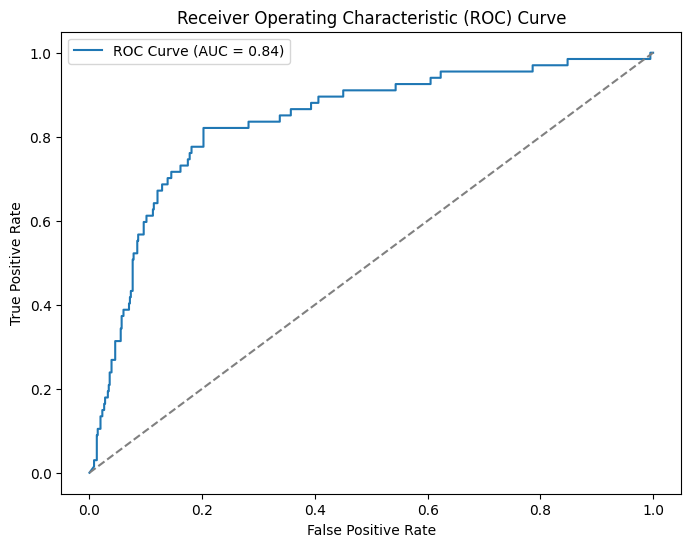

In [87]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba = lda_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

logistic_regression = LogisticRegression()
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
lda = LinearDiscriminantAnalysis()

logistic_regression.fit(X_train, y_train)
random_forest.fit(X_train, y_train)
lda.fit(X_train, y_train)

y_pred_logreg = logistic_regression.predict(X_test)
y_pred_rf = random_forest.predict(X_test)
y_pred_lda = lda.predict(X_test)

metrics = {
    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_logreg),
        "Precision": precision_score(y_test, y_pred_logreg),
        "Recall": recall_score(y_test, y_pred_logreg),
        "F1-score": f1_score(y_test, y_pred_logreg),
        "ROC-AUC": roc_auc_score(y_test, logistic_regression.predict_proba(X_test)[:, 1])
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, random_forest.predict_proba(X_test)[:, 1])
    },
    "LDA": {
        "Accuracy": accuracy_score(y_test, y_pred_lda),
        "Precision": precision_score(y_test, y_pred_lda),
        "Recall": recall_score(y_test, y_pred_lda),
        "F1-score": f1_score(y_test, y_pred_lda),
        "ROC-AUC": roc_auc_score(y_test, lda.predict_proba(X_test)[:, 1])
    }
}

for model, metric_values in metrics.items():
    print(f"\nPerformance Metrics for {model}:")
    for metric, value in metric_values.items():
        print(f"{metric}: {value}")

best_model = max(metrics, key=lambda x: metrics[x]["ROC-AUC"])
print(f"\nBest Model: {best_model}")


Performance Metrics for Logistic Regression:
Accuracy: 0.8661764705882353
Precision: 0.1
Recall: 0.04477611940298507
F1-score: 0.061855670103092786
ROC-AUC: 0.6079472133622263

Performance Metrics for Random Forest:
Accuracy: 0.9205882352941176
Precision: 0.6585365853658537
Recall: 0.40298507462686567
F1-score: 0.5
ROC-AUC: 0.9294270896739791

Performance Metrics for LDA:
Accuracy: 0.8852941176470588
Precision: 0.4126984126984127
Recall: 0.3880597014925373
F1-score: 0.4
ROC-AUC: 0.8377322198144677

Best Model: Random Forest


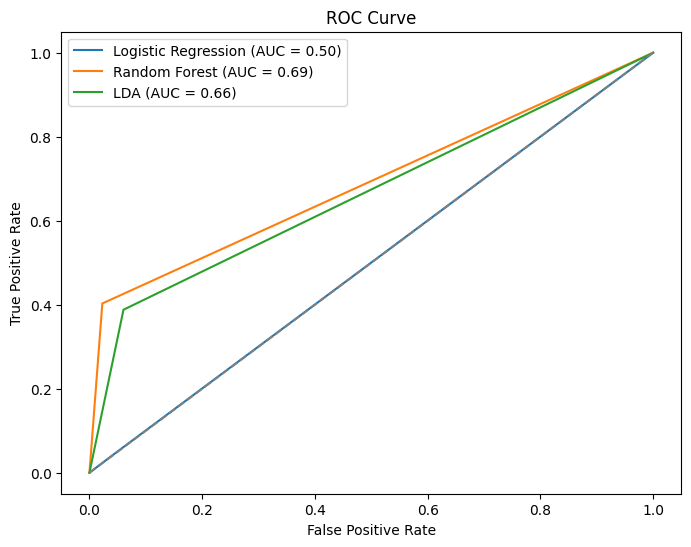

In [90]:
from sklearn.metrics import roc_curve, roc_auc_score

lr_fpr, lr_tpr, _ = roc_curve(y_test, y_pred_logreg)
lr_auc = roc_auc_score(y_test, y_pred_logreg)

rf_fpr, rf_tpr, _ = roc_curve(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_pred_rf)

lda_fpr, lda_tpr, _ = roc_curve(y_test, y_pred_lda)
lda_auc = roc_auc_score(y_test, y_pred_lda)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(lda_fpr, lda_tpr, label=f'LDA (AUC = {lda_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()